# Model Workbench

Same data pipeline, train/val split, and evaluation as `Train_And_Evaluate.ipynb` -- but the model section is left blank for you to fill in. Define one or more architectures in the **"Build your model(s)"** section, register each in `MODEL_REGISTRY`, and the training/eval loop below trains and scores all of them on the identical split, so results are directly comparable.

Metrics are scored against real, QC-valid conductivity observations only, same convention as `Train_And_Evaluate.ipynb` / `scripts/forecast_skill_baseline.py`. Nothing here writes to `checkpoints/`.

In [1]:
import os, sys
_here = os.getcwd()
if os.path.basename(_here) == "notebooks":
    os.chdir(os.path.dirname(_here))
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import inspect

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from strawberrywatch import paths
from strawberrywatch.config import Config
from strawberrywatch.ingest.data_loader import load_and_preprocess_data
from strawberrywatch.utils.graph_utils import create_graph_topology
from strawberrywatch.preprocessing.data_processor import prepare_sequences_normalized
from strawberrywatch.training.trainer import train_temporal_gnn

# Register each model you build below as name -> class. The training/eval
# loop iterates over this dict, so adding a second or third architecture
# is just another entry here, not a new notebook.
MODEL_REGISTRY = {}

## Config

In [2]:
MIN_EVALUABLE = 200  # per-node sample floor below which metrics are not trusted

CORPUS_PATH = paths.training_corpus()
LAG_15MIN = pd.Timedelta(minutes=15)

# Shared training hyperparameters, applied to every model in MODEL_REGISTRY.
# Override per-model inside the training loop below if you need to.
TRAIN_KWARGS = {
    "epochs": Config.EPOCHS,
    "batch_size": Config.BATCH_SIZE,
    "learning_rate": Config.LEARNING_RATE,
}

## Data Visualization

In [24]:
corpus_raw = pd.read_csv(CORPUS_PATH)
corpus_raw["datetime"] = pd.to_datetime(corpus_raw["datetime"]).dt.tz_localize(None)

corpus_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 32440 entries, 0 to 32439
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   datetime                   32440 non-null  datetime64[us]
 1   north_fork_0_conductivity  30048 non-null  float64       
 2   north_fork_0_depth         30048 non-null  float64       
 3   north_fork_0_temperature   30048 non-null  float64       
 4   south_fork_2_conductivity  31030 non-null  float64       
 5   south_fork_2_depth         31030 non-null  float64       
 6   south_fork_2_temperature   31030 non-null  float64       
 7   south_fork_1_conductivity  23420 non-null  float64       
 8   south_fork_1_depth         23420 non-null  float64       
 9   south_fork_1_temperature   23420 non-null  float64       
 10  oxford_conductivity        32140 non-null  float64       
 11  oxford_depth               31557 non-null  float64       
 12  oxford_temperat

In [25]:
corpus_raw.describe()

,datetime,north_fork_0_conductivity,north_fork_0_depth,north_fork_0_temperature,south_fork_2_conductivity,south_fork_2_depth,south_fork_2_temperature,south_fork_1_conductivity,south_fork_1_depth,south_fork_1_temperature,oxford_conductivity,oxford_depth,oxford_temperature,air_temp_c,rain_mm,shortwave_radiation,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos
count,32440,30048.000000,30048.000000,30048.000000,31030.000000,31030.000000,31030.000000,23420.000000,23420.000000,23420.000000,32140.000000,31557.000000,32140.000000,32440.000000,32440.000000,32440.000000,32440.000000,3.244000e+04,32440.000000,32440.000000
mean,2025-11-20 02:22:30,528.565848,232.925868,15.031035,605.490795,516.595682,15.237485,582.760162,78.662012,15.544665,338.901170,120.721906,13.637909,14.188021,0.010358,156.302744,-0.000142,-1.982088e-04,-0.052953,0.059196
min,2025-06-04 03:30:00,13.200000,1.000000,7.080000,66.300000,481.800000,8.900000,60.700000,40.600000,8.200000,194.900000,0.112776,5.200000,2.300000,0.000000,0.000000,-1.000000,-1.000000e+00,-0.999991,-0.999963
25%,2025-08-27 14:56:15,504.500000,200.000000,13.700000,567.700000,502.000000,13.700000,562.700000,57.300000,13.900000,315.500000,103.632000,11.500000,11.500000,0.000000,0.000000,-0.707107,-7.071068e-01,-0.746972,-0.577292
50%,2025-11-20 02:22:30,536.500000,211.500000,15.200000,607.800000,507.800000,15.300000,600.800000,62.300000,15.900000,346.600000,112.776000,13.800000,13.700000,0.000000,0.000000,0.000000,-1.836970e-16,-0.120208,0.124479
75%,2026-02-12 13:48:45,603.300000,238.700000,16.400000,672.700000,520.200000,16.800000,637.000000,82.200000,17.220000,369.800000,121.920000,15.900000,16.300000,0.000000,243.000000,0.707107,7.071068e-01,0.661635,0.749826
max,2026-05-08 01:15:00,672.200000,1193.200000,332.000000,821.200000,934.700000,20.420000,796.500000,511.300000,20.600000,442.700000,658.368000,18.900000,31.200000,7.800000,1040.000000,1.000000,1.000000e+00,0.999991,1.000000
std,NaN,105.450115,59.886340,2.722279,116.966548,30.191261,2.056565,109.273173,38.518859,2.161483,44.954634,37.927272,2.536706,3.922972,0.128732,251.293817,0.707144,7.070909e-01,0.708166,0.701586


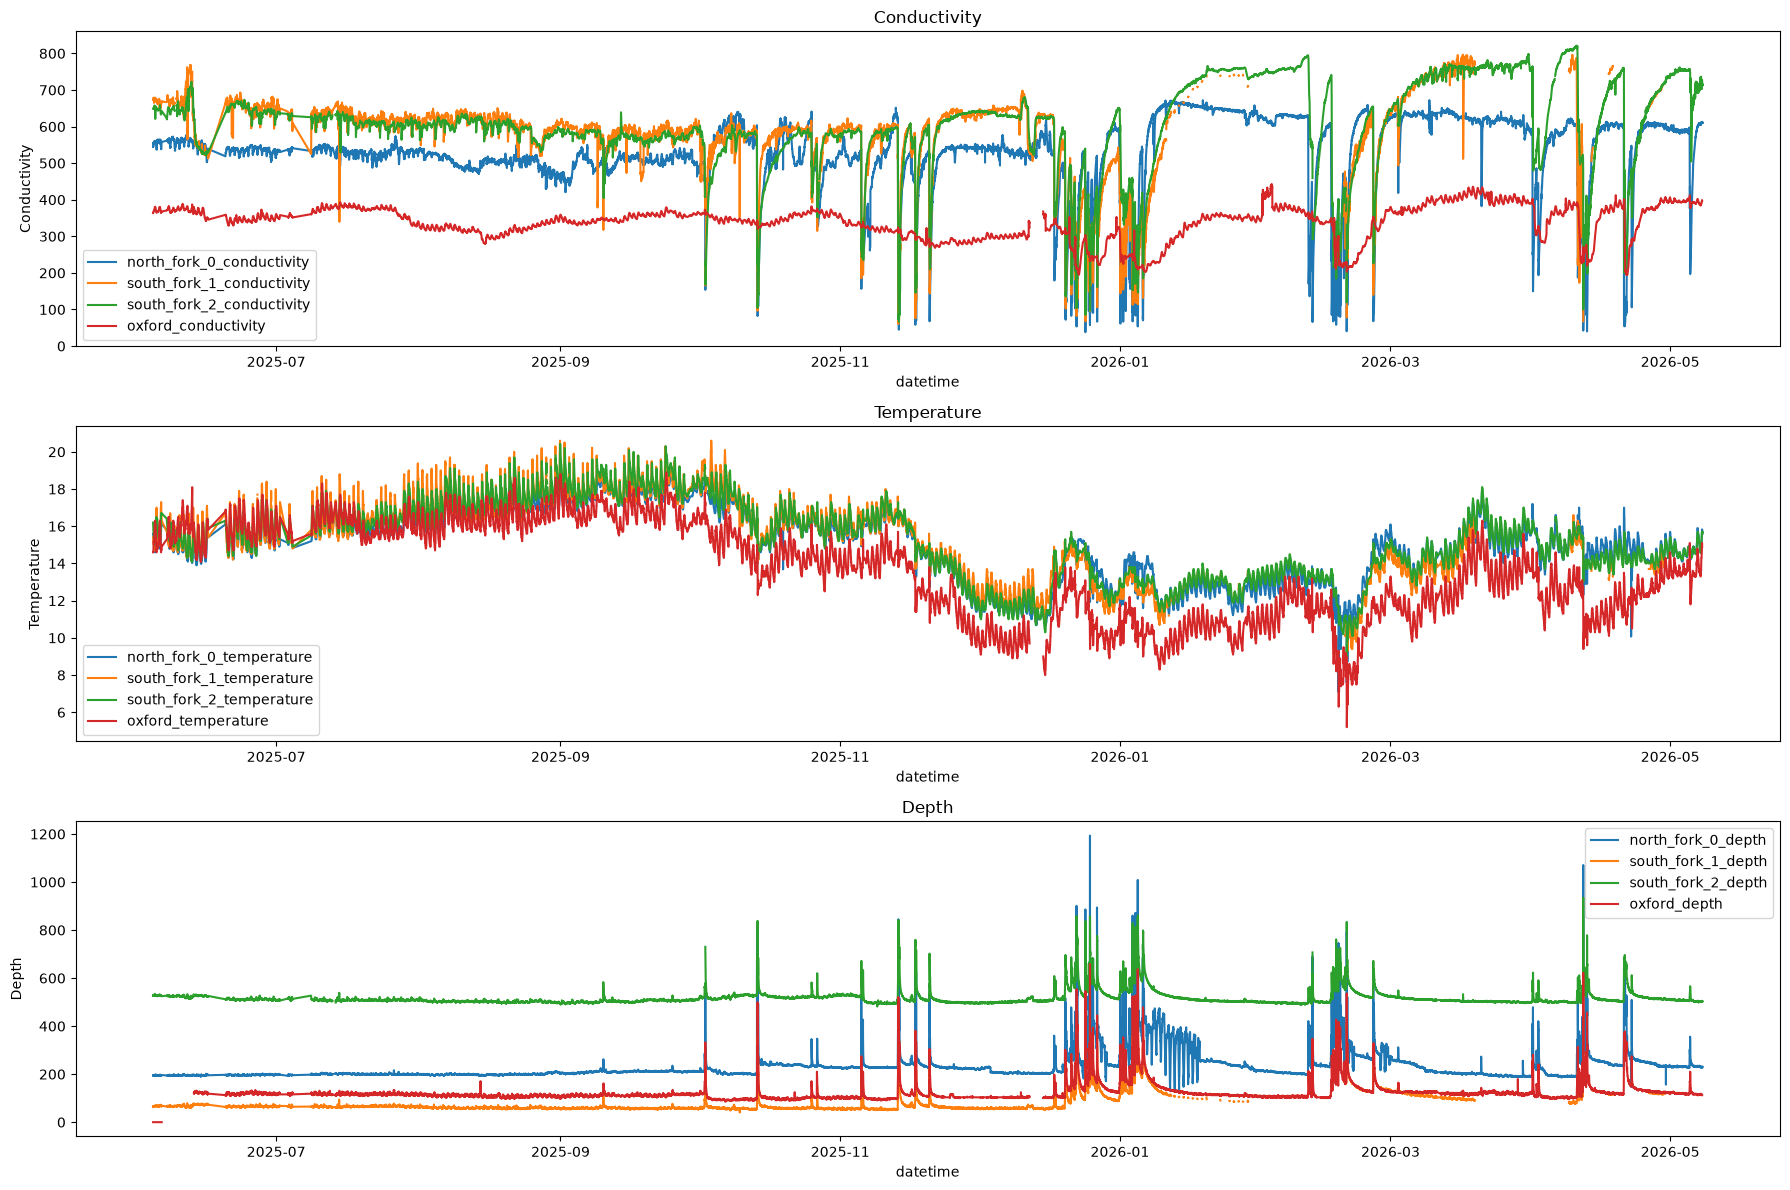

In [58]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 12))

titles = {ax1: 'Conductivity', ax2: 'Temperature', ax3: 'Depth'}

suffixes = {ax1: 'conductivity', ax2: 'temperature', ax3: 'depth'}
sites = ['north_fork_0', 'south_fork_1', 'south_fork_2', 'oxford']
groups = {ax: [f'{site}_{suffix}' for site in sites] for ax, suffix in suffixes.items()}

for ax, cols in groups.items():
    for col in cols:
        ax.plot(corpus_raw['datetime'], corpus_raw[col], label = col)
    ax.set_title(titles[ax])
    ax.set_xlabel('datetime')
    ax.set_ylabel(titles[ax])
    ax.legend()

plt.tight_layout()
plt.show()

In [61]:
# remove outliers
corpus_raw_filtered = corpus_raw[corpus_raw['north_fork_0_temperature'] < 50]
filter_cond_cols = [f'{site}_conductivity' for site in sites[:3]]
corpus_raw_filtered = corpus_raw_filtered[(corpus_raw_filtered[filter_cond_cols] != 0).all(axis=1)]

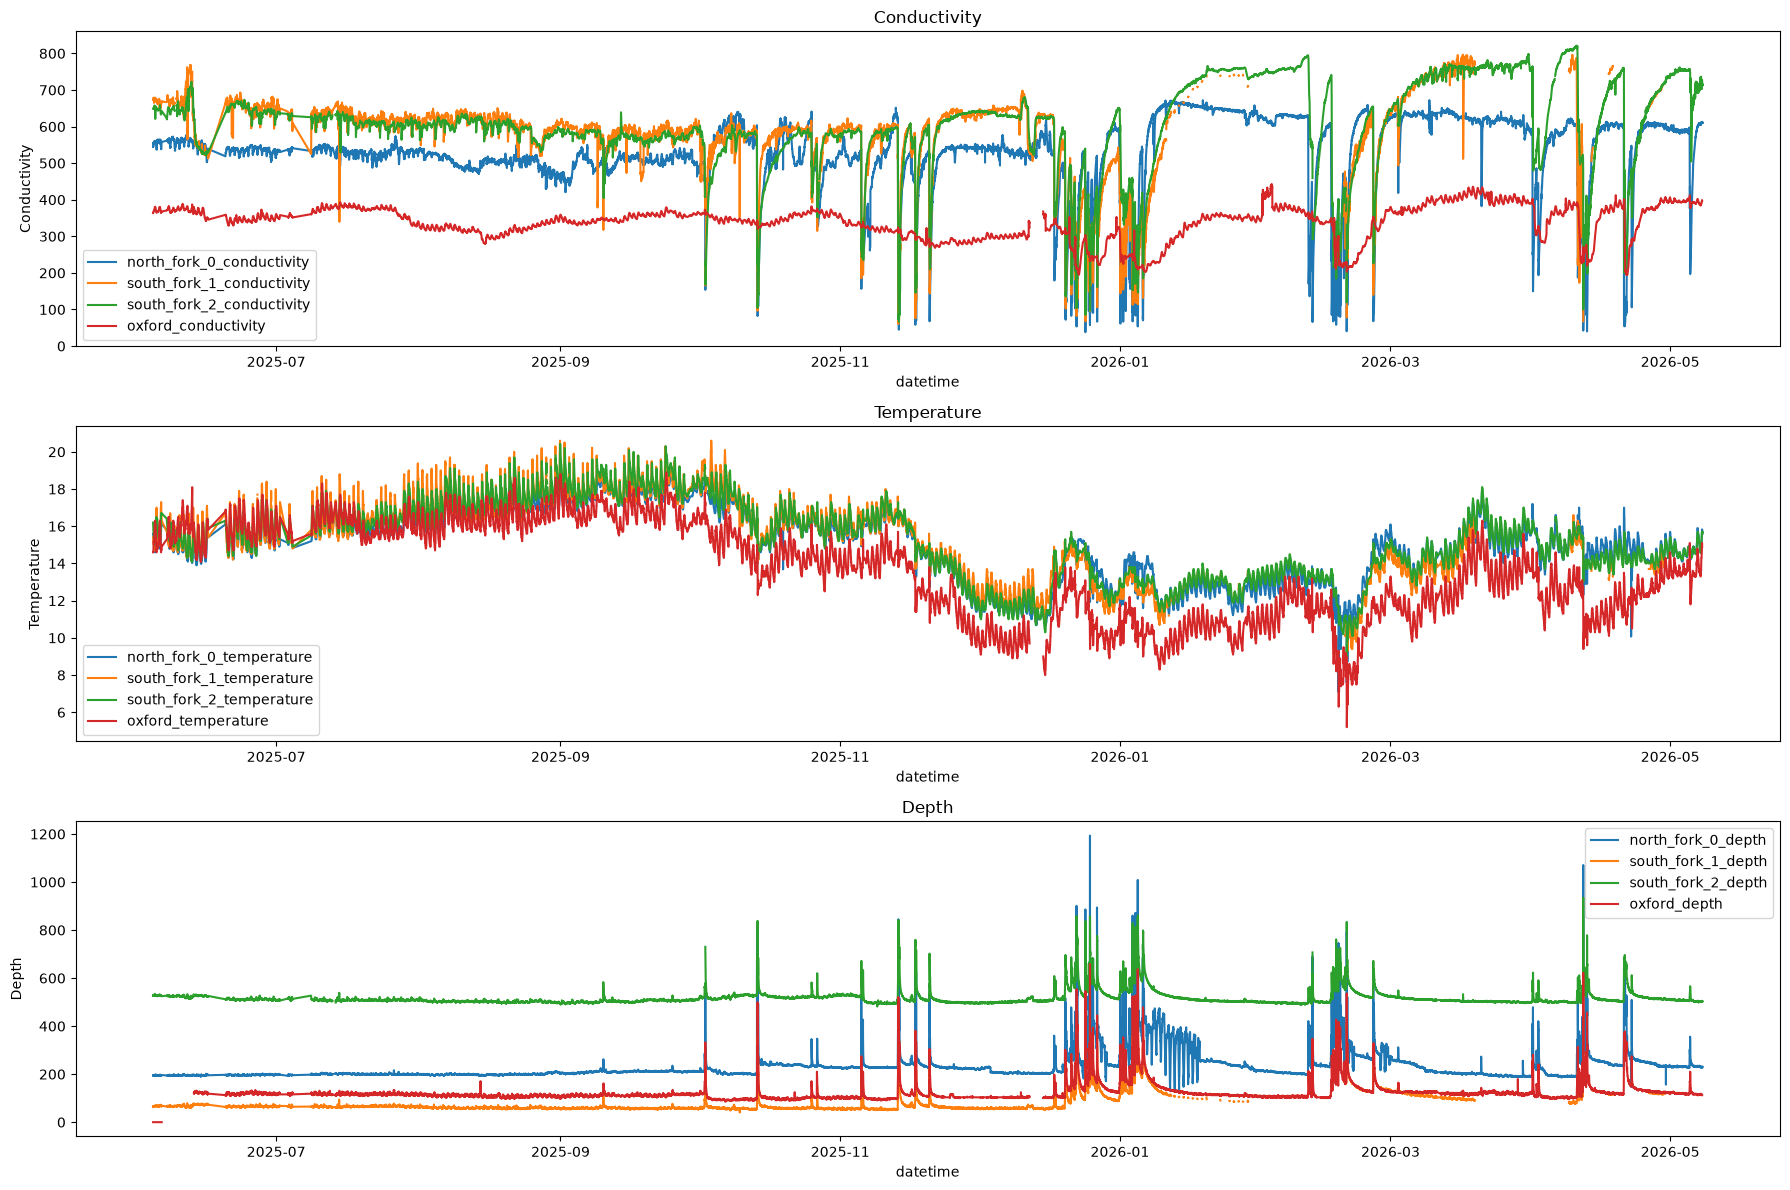

In [63]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 12))

titles = {ax1: 'Conductivity', ax2: 'Temperature', ax3: 'Depth'}

suffixes = {ax1: 'conductivity', ax2: 'temperature', ax3: 'depth'}
sites = ['north_fork_0', 'south_fork_1', 'south_fork_2', 'oxford']
groups = {ax: [f'{s}_{suf}' for s in sites] for ax, suf in suffixes.items()}

for ax, cols in groups.items():
    for col in cols:
        ax.plot(corpus_raw_filtered['datetime'], corpus_raw_filtered[col], label=col)
    ax.set_title(titles[ax])
    ax.set_xlabel('datetime')
    ax.set_ylabel(titles[ax])
    ax.legend()

plt.tight_layout()
plt.show()


## Build the train/val split

Chronological split over the full corpus via `Config.TRAIN_SPLIT`, same as `main.py --mode train` and `Train_And_Evaluate.ipynb`. This produces `edge_index`, the normalized sequence tensors, and the node/target masks that any model in `MODEL_REGISTRY` trains and evaluates against.

In [45]:
edge_index, _, location_to_idx = create_graph_topology()
df_featured, _, _ = load_and_preprocess_data(file_path=CORPUS_PATH, force_download=True, days=999)
sequences, targets, timestamps, scaler, feature_cols, node_mask_seq, target_mask = (
    prepare_sequences_normalized(
        df_featured, location_to_idx, Config.SEQUENCE_LENGTH, return_node_mask=True
    )
)

split_idx = int(len(sequences) * Config.TRAIN_SPLIT)
train_seq, val_seq = sequences[:split_idx], sequences[split_idx:]
train_tgt, val_tgt = targets[:split_idx], targets[split_idx:]
train_node_mask, val_node_mask = node_mask_seq[:split_idx], node_mask_seq[split_idx:]
train_target_mask, val_target_mask = target_mask[:split_idx], target_mask[split_idx:]
val_ts = pd.DatetimeIndex(timestamps[split_idx:])
node_names = list(location_to_idx.keys())
num_nodes = len(node_names)
num_features = len(feature_cols)

print(f"train sequences: {len(train_seq):,}, val sequences: {len(val_seq):,}")
print(f"val range: {val_ts[0]} -> {val_ts[-1]}")
print(f"num_nodes={num_nodes}, num_features={num_features}, feature_cols={feature_cols}")

graph topology: 4 nodes, 3 edges, device=cpu

'/Users/1an/Desktop/Projects/School/StrawberryWatch/data/processed_data/training_corpus.csv' is a wide training corpus (has *_valid columns); loading directly, skipping fetch/merge.
wide corpus converted: 4 sites x 32,440 timesteps -> 129,760 long rows
data loaded:
Rows: 129,760
Range: 2025-06-04 03:30:00+00:00 to 2026-05-08 01:15:00+00:00
Sites present (4): ['north_fork_0', 'oxford', 'south_fork_1', 'south_fork_2']
Active features (10): conductivity, depth, temperature, rain_mm, air_temp_c, shortwave_radiation, hour_sin, hour_cos, dayofyear_sin, dayofyear_cos
---------------------------

using 10 features: conductivity, depth, temperature, rain_mm, air_temp_c, shortwave_radiation, hour_sin, hour_cos, dayofyear_sin, dayofyear_cos
imputing gaps up to 24h (96 rows)...
  [north_fork_0] filled 5268 missing values
  [oxford] filled 408 missing values
  [south_fork_1] filled 8784 missing values
  [south_fork_2] filled 2325 missing values
filled 1

Pivoting data:  41%|████      | 13337/32440 [00:05<00:08, 2230.37it/s]


KeyboardInterrupt: 

## Build your model(s) here

Each model is a plain `nn.Module` that must match this interface so the shared training loop, `run_model_over`, and metrics below work unmodified:

- `__init__(self, num_node_features, num_nodes=None, ...)` -- `num_nodes` is only passed in if your `__init__` signature declares it (checked via `inspect.signature`), so it's optional.
- `forward(self, x_sequence, edge_index, batch_size, num_nodes, node_mask=None)`:
  - `x_sequence`: `(batch, seq_len, num_nodes, num_features)` float tensor, already normalized.
  - `edge_index`: PyG-style `(2, num_edges)` long tensor, directed flow graph.
  - `node_mask`: optional `(batch, seq_len, num_nodes)` bool tensor, True where a node has real (non-missing) data at that timestep. Only passed in if `forward` declares a `node_mask` parameter -- fine to omit if you don't want to handle missing sensors.
  - Return: `(batch, num_nodes, num_features)` -- a normalized-space prediction for every feature at the next timestep. `train_temporal_gnn` only scores the subset of features in `Config.TARGET_FEATURES` (conductivity, depth, temperature), so the rest can be near-arbitrary, but the shape must match.

`strawberrywatch/models/Dusk_Crayfish.py` (`DuskCrayfish`) is a worked example of a model that satisfies this interface -- worth a skim before writing your own, particularly for how it handles `node_mask` and predicts a delta off the last observed reading rather than an absolute value from scratch.

Define as many model classes as you want, one per cell, and register each at the end:
```python
MODEL_REGISTRY["my_model"] = MyModel
```

In [ ]:
# Model 1 -- build it here.
#
# class MyModel(nn.Module):
#     def __init__(self, num_node_features, num_nodes=None):
#         super().__init__()
#         ...
#
#     def forward(self, x_sequence, edge_index, batch_size, num_nodes, node_mask=None):
#         ...
#         return predictions  # (batch, num_nodes, num_features)
#
# MODEL_REGISTRY["my_model"] = MyModel

In [ ]:
# Model 2 (optional) -- add more cells like this for each additional architecture.

## Train and evaluate every registered model

Trains each entry in `MODEL_REGISTRY` from scratch on the same split with the same `TRAIN_KWARGS`, then runs it over the held-out split and scores it with the same metrics (`mae`, `rmse`, `mase`, `smape`, `r2`, `directional_accuracy`) as `Train_And_Evaluate.ipynb`, computed against real, QC-valid conductivity only.

In [ ]:
def run_model_over(model, edge_index, seq, node_mask, num_nodes, batch_size=256):
    """Batched forward pass, node_mask passed only if the model's forward() accepts it."""
    supports_mask = "node_mask" in inspect.signature(model.forward).parameters
    preds = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(seq), batch_size):
            seq_t = torch.FloatTensor(seq[i:i + batch_size]).to(Config.DEVICE)
            kwargs = dict(batch_size=len(seq_t), num_nodes=num_nodes)
            if supports_mask:
                kwargs["node_mask"] = torch.BoolTensor(node_mask[i:i + batch_size]).to(Config.DEVICE)
            preds.append(model(seq_t, edge_index, **kwargs).cpu().numpy())
    return np.concatenate(preds, axis=0)


def mae(actual, pred):
    return float(np.mean(np.abs(actual - pred)))


def rmse(actual, pred):
    return round(float(np.sqrt(np.mean((actual - pred) ** 2))), 2)


def mape(actual, pred):
    return float(np.mean(np.abs((actual - pred) / actual)) * 100)


def smape(actual, pred):
    denom = np.abs(actual) + np.abs(pred)
    denom = np.where(denom == 0, 1.0, denom)
    return float(100 * np.mean(2 * np.abs(actual - pred) / denom))


def r2(actual, pred):
    ss_res = np.sum((actual - pred) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")


def directional_accuracy(actual, pred, prev):
    """Fraction of steps where the model got the sign of the change right, not just its size."""
    return float(np.mean(np.sign(actual - prev) == np.sign(pred - prev)))


corpus = pd.read_csv(CORPUS_PATH)
corpus["datetime"] = pd.to_datetime(corpus["datetime"], utc=True)
corpus = corpus.set_index("datetime")
t_minus_1 = val_ts - LAG_15MIN
cond_idx = feature_cols.index("conductivity")
cond_mean, cond_scale = scaler.mean_[cond_idx], scaler.scale_[cond_idx]


def compute_metrics_table(preds_raw_cond):
    """Per-node mae/rmse/mase/mape/smape/r2/directional_accuracy against real, QC-valid conductivity."""
    rows = []
    for node_idx, site in enumerate(node_names):
        raw_cond = corpus[f"{site}_conductivity"]
        qc_valid = corpus[f"{site}_valid"].astype(bool)
        target_raw = raw_cond.reindex(val_ts)
        valid = qc_valid.reindex(val_ts).fillna(False)
        persist_raw = raw_cond.reindex(t_minus_1)
        persist_raw.index = val_ts

        keep = target_raw.notna().to_numpy() & valid.to_numpy() & persist_raw.notna().to_numpy()
        n = int(keep.sum())
        if n < MIN_EVALUABLE:
            rows.append({"node": site, "n": n, "mae": np.nan, "rmse": np.nan, "mase": np.nan,
                         "mape": np.nan, "smape": np.nan, "r2": np.nan, "directional_accuracy": np.nan})
            continue

        actual = target_raw.to_numpy()[keep]
        prev = persist_raw.to_numpy()[keep]
        pred = preds_raw_cond[keep, node_idx]
        mae_naive = mae(actual, prev)

        rows.append({
            "node": site,
            "n": n,
            "mae": mae(actual, pred),
            "rmse": rmse(actual, pred),
            "mase": mae(actual, pred) / mae_naive if mae_naive > 0 else float("nan"),
            "mape": mape(actual, pred),
            "smape": smape(actual, pred),
            "r2": r2(actual, pred),
            "directional_accuracy": directional_accuracy(actual, pred, prev),
        })
    return pd.DataFrame(rows).set_index("node")


def run_experiment(name, ModelClass, train_kwargs=TRAIN_KWARGS):
    """Fresh model, trained in memory. Returns loss curves + per-node metrics, nothing written to disk."""
    print(f"=== {name} ===")

    model_kwargs = {"num_node_features": num_features}
    if "num_nodes" in inspect.signature(ModelClass.__init__).parameters:
        model_kwargs["num_nodes"] = num_nodes
    model = ModelClass(**model_kwargs).to(Config.DEVICE)

    train_losses, val_losses, threshold, _ = train_temporal_gnn(
        model,
        train_seq, train_tgt, edge_index,
        val_sequences=val_seq, val_targets=val_tgt,
        feature_cols=feature_cols,
        train_node_mask=train_node_mask, val_node_mask=val_node_mask,
        train_target_mask=train_target_mask, val_target_mask=val_target_mask,
        **train_kwargs,
    )

    preds_norm = run_model_over(model, edge_index, val_seq, val_node_mask, num_nodes)
    preds_raw_cond = preds_norm[:, :, cond_idx] * cond_scale + cond_mean
    metrics_df = compute_metrics_table(preds_raw_cond)

    return {
        "name": name,
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "threshold": threshold,
        "metrics": metrics_df,
    }


results = [run_experiment(name, ModelClass) for name, ModelClass in MODEL_REGISTRY.items()]

## Compare results

One row per registered model: final train/val loss plus mae/rmse/mase/mape/smape/r2/directional_accuracy averaged across nodes with enough evaluable points, followed by val-loss curves overlaid across all models.

In [ ]:
summary_rows = []
for r in results:
    m = r["metrics"]
    summary_rows.append({
        "name": r["name"],
        "final_train_loss": r["train_losses"][-1],
        "final_val_loss": r["val_losses"][-1],
        "avg_mae": m["mae"].mean(),
        "avg_rmse": m["rmse"].mean(),
        "avg_mase": m["mase"].mean(),
        "avg_mape": m["mape"].mean(),
        "avg_smape": m["smape"].mean(),
        "avg_r2": m["r2"].mean(),
        "avg_directional_accuracy": m["directional_accuracy"].mean(),
    })

summary = pd.DataFrame(summary_rows).set_index("name")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
summary

In [ ]:
plt.figure(figsize=(8, 5))
for r in results:
    plt.plot(r["val_losses"], label=r["name"], marker="o", markersize=3)
plt.xlabel("epoch")
plt.ylabel("val loss")
plt.title("Val loss by model")
plt.legend()
plt.show()